In [14]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
job_array=False;index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [7]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [8]:
#DOMAIN SUBSETTING
############################################################
ocean_percent=2/8

left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
end_xh=len(data['xh'])-1-50
end_xf=len(data['xf'])-1-50

print(f'x in {0}:{where_coast_xh-1} FOR SEA')
print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
# t_end=78 
# if res=='250m':t_end=410
# print(f't in {0}:{t_end} (6.5 hours)')
t_start=36 
print(f't in {t_start}:end (8 hours)')


#SUBSETTING CODE
A_g[(X<where_coast_xh)|(X>end_xh)]=0
A_c[(X<where_coast_xh)|(X>end_xh)]=0
A_g[0:t_start]=0
A_c[0:t_start]=0

x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)


In [9]:
def call_variables(t): 
    if np.mod(t,25)==0: print(f'loading variables for time {t}')
    # variable='w'; w_data=data[variable].isel(time=t).interp(zf=data['zh']).data #get w_data and interpolation w data z coordinate from zh to zf
    variable='winterp'; w_data=data[variable].isel(time=t).data
    variable='qv'; qv_data=data[variable].isel(time=t).data # get qc data
    variable='qc'; qc_data=data[variable].isel(time=t).data # get qc data
    variable='qi'; qi_data=data[variable].isel(time=t).data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].isel(time=t).data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].isel(time=t).data # get qc data
    
    import h5py
    with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}_{Np_str}'+'.h5', 'r') as f:
        theta_e_data = f['theta_e'][t]

    return w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data


In [10]:
#TESTING ********************

def LagrangianProfiles(type):
    print(f'currently working on type {type}')
    
    #Create Storage Arrays for All Variables
    vars=['w','qv','qc','qi','th','th_e','buoyancy']
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs
    
    Nt=len(data['time'])
    for t in np.arange(Nt):
        # if np.mod(t,20)==0: print(f"time {t}")
        
        #Call Variables and Store in a Dictionary
        [w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data]=call_variables(t)
        var_data_map = {
            'w': w_data,
            'qv': qv_data,
            'qc': qc_data,
            'qi': qi_data,
            'th': th_data,
            'th_e': theta_e_data,
            'buoyancy': buoyancy_data
            }
    
        #Get the Lagrangian Parcel Grid Locations
        if type=='general':
            where_g=np.where(A_g[t,:]==1)
            zs=Z[t,where_g[0]]
            ys=Y[t,where_g[0]]
            xs=X[t,where_g[0]]
        if type=='cloudy':
            where_c=np.where(A_c[t,:]==1)
            zs=Z[t,where_c[0]]
            ys=Y[t,where_c[0]]
            xs=X[t,where_c[0]]
    
        #For Each Variable, Link profile_array to profile_{var} and Add Profile Elements to Storage Array
        for var in vars:
            profile_array = globals()[f"profile_{var}"]
            var_data = var_data_map[var]
            
            np.add.at(profile_array[:, 0], zs, var_data[zs, ys, xs])
            np.add.at(profile_array[:, 1], zs, 1)
    
        # position = (zs.flatten(), ys.flatten(), xs.flatten())
        # for (z, y, x) in zip(*position):
        #     var=var_data[z,y,x]
        #     profile_array[z,0]+=var;profile_array[z,1]+=1
            
        del w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data

    
    #OUTPUTTING RESULTS       
    if type=='general':
        output_file=dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_{res}_{Np_str}.h5'
    elif type=='cloudy':
        output_file=dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_{res}_{Np_str}.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
        f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_th_e', data=profile_th_e, compression="gzip")
        f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
    print('done\n')

In [11]:
#RUNNING
LagrangianProfiles(type='general')
LagrangianProfiles(type='cloudy')    

currently working on type general
loading variables for time 0
loading variables for time 25
loading variables for time 50
loading variables for time 75
loading variables for time 100
loading variables for time 125
done

currently working on type cloudy
loading variables for time 0
loading variables for time 25
loading variables for time 50
loading variables for time 75
loading variables for time 100
loading variables for time 125
done



In [2]:
#######################################################################################################################################
#Calling Data and Plotting Next

In [21]:
##################
# Plotting

In [12]:
#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6

currently on type general
currently on type cloudy


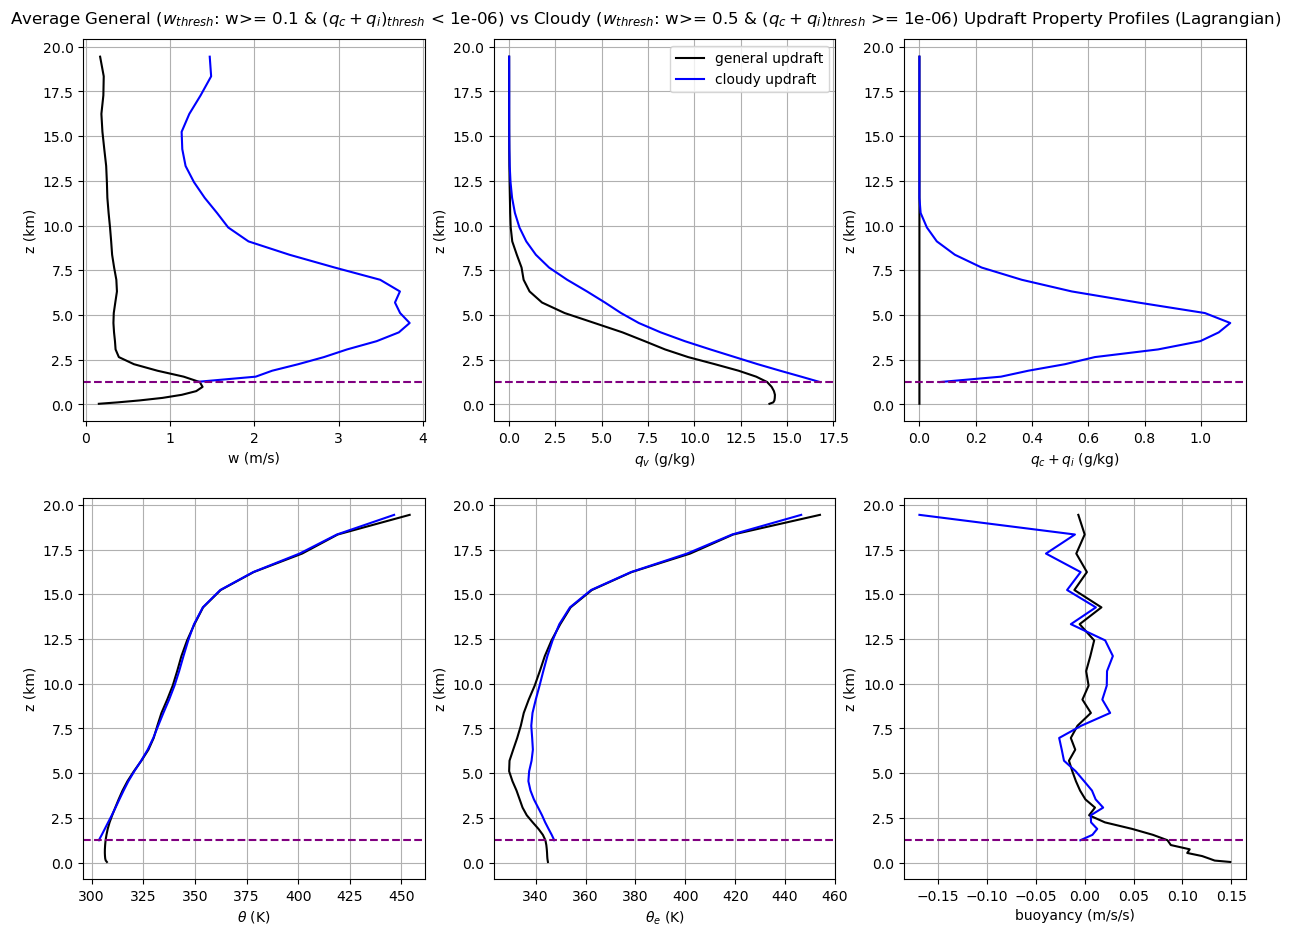

In [15]:
#Plotting (for all variables)
import h5py

# Produced averaged profiles for plotting
def averaged_profiles(var):
    profile = globals()[f"profile_{var}"]
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

####################################################################
res = '1km'
# res = '250m'
label=1

# Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Profiles (Lagrangian)")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
fig.subplots_adjust(top=0.95)
####################################################################
for type in ["general", "cloudy"]:
    print(f'currently on type {type}')

    if res=='1km':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_{res}_{Np_str}.h5'
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_{res}_{Np_str}.h5' 
    
    if res=='250m':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/250m_general_lagrangian_profiles_{res}_{Np_str}.h5' 
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_{res}_{Np_str}.h5' 
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
        profile_th_e = np.array(f['profile_th_e'])
        profile_buoyancy = np.array(f['profile_buoyancy'])
            
    # #adding qc and qi profile together #QC IS ACTUALLY ALREADY QC_PLUS_QI
    # profile_qc[:,0]+=profile_qi[:,0] 
    # profile_qc[:,1]+=profile_qi[:,1] 

    for var in ['qv','qc']:
        globals()[f"profile_{var}"][:,0]*=1000
    
    # Plotting function
    def plotting(out_var, axis, label, color):
        axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color)
        axis.grid(True)
    
    # Uses Averaged_Profiles Function
    vars = ['w', 'qv', 'qc', 'th','th_e','buoyancy']
    # vars = ['w']  # TESTING
    for var in vars:
        globals()[f"out_{var}"] = averaged_profiles(var)
    
    axises = [ax1, ax2, ax3, ax4, ax5, ax6]
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for var, axis, xlabel in zip(vars, axises, xlabels):
        if type == 'general':
            color = 'k'
        elif type == 'cloudy':
            color = 'blue'
        plotting(globals()[f"out_{var}"], axis, label=type + ' updraft', color=color)
        axis.set_ylabel('z (km)')
        axis.set_xlabel(xlabel)
        if axis==ax2:
            axis.legend()  # add legend
############################

#MEAN CLOUD BASE
qcqi_profile=averaged_profiles('qc')
where_cloudbase=np.where(qcqi_profile[:,0]>=qcqi_thresh)[0][0]
cloudbase=qcqi_profile[where_cloudbase,1]
for axis in axises:
    axis.axhline(cloudbase,color='purple',linestyle='dashed')


#save plot
if res == '1km':
    plt.savefig(dir+f'Project_Algorithms/plots/1km_lagrangian_generalvscloudy_updraft_profile_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"
elif res == '250m':
    plt.savefig(dir+f'Project_Algorithms/plots/250m_lagrangian_generalvscloudy_updraft_profile_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"


In [82]:
# #CTRL Plotting (for all variables)
# import h5py

# # Produced averaged profiles for plotting
# def averaged_profiles(var):
#     profile = globals()[f"profile_{var}"]
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

# ####################################################################
# res = '1km'
# # res = '250m'

# # Uses Plotting Function 
# fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# fig.suptitle(f"Average Lagrangian Non-General vs Non-Cloudy Updraft CTRL Property Profiles")
# ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
# fig.subplots_adjust(top=0.95)
# ####################################################################
# for type in ["general", "cloudy"]:
#     print(f'currently on type {type}')

#     if res=='1km':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_CTRL_{res}_{Np_str}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_CTRL_{res}_{Np_str}.h5' 
    
#     if res=='250m':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/250m_general_lagrangian_profiles_CTRL_{res}_{Np_str}.h5' 
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_CTRL_{res}_{Np_str}.h5' 
    
#     with h5py.File(input_file, 'r') as f:
#         profile_w = np.array(f['profile_w'])
#         profile_qv = np.array(f['profile_qv'])
#         profile_qc = np.array(f['profile_qc'])
#         profile_qi = np.array(f['profile_qi'])
#         profile_th = np.array(f['profile_th'])
#         profile_buoyancy = np.array(f['profile_buoyancy'])
            
#     #adding qc and qi profile together
#     profile_qc[:,0]+=profile_qi[:,0] 
#     profile_qc[:,1]+=profile_qi[:,1] 

#     for var in ['qv','qc']:
#         globals()[f"profile_{var}"][:,0]*=1000
    
#     # Plotting function
#     def plotting(out_var, axis, label, color):
#         axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color)
#         axis.grid(True)
    
#     # Uses Averaged_Profiles Function
#     vars = ['w', 'qv', 'qc', 'th','buoyancy']
#     # vars = ['w']  # TESTING
#     for var in vars:
#         globals()[f"out_{var}"] = averaged_profiles(var)
    
#     axises = [ax1, ax2, ax3, ax4, ax5]
#     xlabels = ['w (m/s)', 'qv (g/kg)', 'qc + qi (g/kg)', 'th (K)', 'buoyancy (m/s/s)']
#     for var, axis, xlabel in zip(vars, axises, xlabels):
#         if type == 'general':
#             color = 'k'
#         elif type == 'cloudy':
#             color = 'blue'
#         plotting(globals()[f"out_{var}"], axis, label=type + ' updraft', color=color)
#         axis.set_ylabel('z (km)')
#         axis.set_xlabel(xlabel)
#         if axis==ax2:
#             axis.legend()  # add legend
# ############################

# #save plot
# if res == '1km':
#     plt.savefig(dir+f'Project_Algorithms/plots/1km_lagrangian_generalvscloudy_updraft_profile_CTRL_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"
# elif res == '250m':
#     plt.savefig(dir+f'Project_Algorithms/plots/250m_lagrangian_generalvscloudy_updraft_profile_CTRL_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"


currently on type general
currently on type cloudy


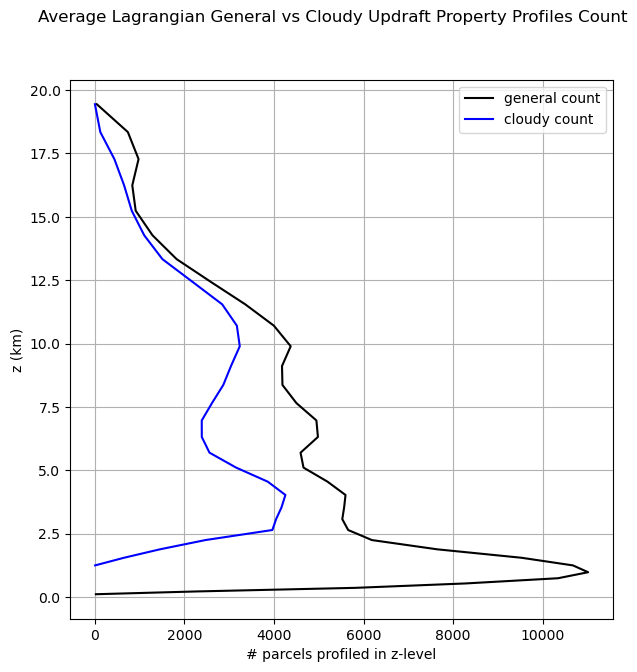

In [13]:
# #Plotting counter column
# res='1km'
# # res='250m'

# #Uses CounterPlotting Function
# fig, axs = plt.subplots(1,1, figsize=(7,7))
# fig.suptitle(f"Average Lagrangian General vs Cloudy Updraft Property Profiles Count")
# # fig.suptitle(f"average lagrangian cloudy updraft property profiles") #uncomment if "cloudy updrafts"
# # ax1 = axs.flatten()
# # plt.tight_layout()
# types=["general","cloudy"]
# for type in types:
#     print(f'currently on type {type}')

#     if res=='1km':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_{res}_{Np_str}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_{res}_{Np_str}.h5' 
    
#     if res=='250m':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/250m_general_lagrangian_profiles_{res}_{Np_str}.h5' 
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_{res}_{Np_str}.h5' 
    
#     with h5py.File(input_file, 'r') as f:
#         profile_w = np.array(f['profile_w'])
#         profile_qv = np.array(f['profile_qv'])
#         profile_qc = np.array(f['profile_qc'])
#         profile_qi = np.array(f['profile_qi'])
#         profile_th = np.array(f['profile_th'])
#         profile_buoyancy = np.array(f['profile_buoyancy'])



#     def counter_plotting(out_var,axis,label,color):
#         out_var=out_var[ (out_var[:, 1] != 0)];
#         axis.plot(out_var[:,1],out_var[:,2],label=label,color=color)
#         axis.grid(True)

#         # print(np.sum(out_var[:,1])) #TESTING
    
#     vars=['w']
#     axises=[axs]
#     xlabels=['# parcels profiled in z-level']
#     for var,axis,xlabel in zip(vars,axises,xlabels):
#         if type=='general':
#             color='k'
#         elif type=='cloudy':
#             color='blue'
#         counter_plotting(globals()[f"profile_{var}"],axis,label=type+' count',color=color)
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
#         axis.legend();
#     ############################# 
#     #save plot
#     dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
#     if res=='1km':
#         plt.savefig(dir+f'Project_Algorithms/plots/1km_lagrangian_generalvscloudy_updraft_profile_counter_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) 
#     if res=='250m':
#         plt.savefig(dir+f'Project_Algorithms/plots/250m_lagrangian_generalvscloudy_updraft_profile_counter_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) 

In [44]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

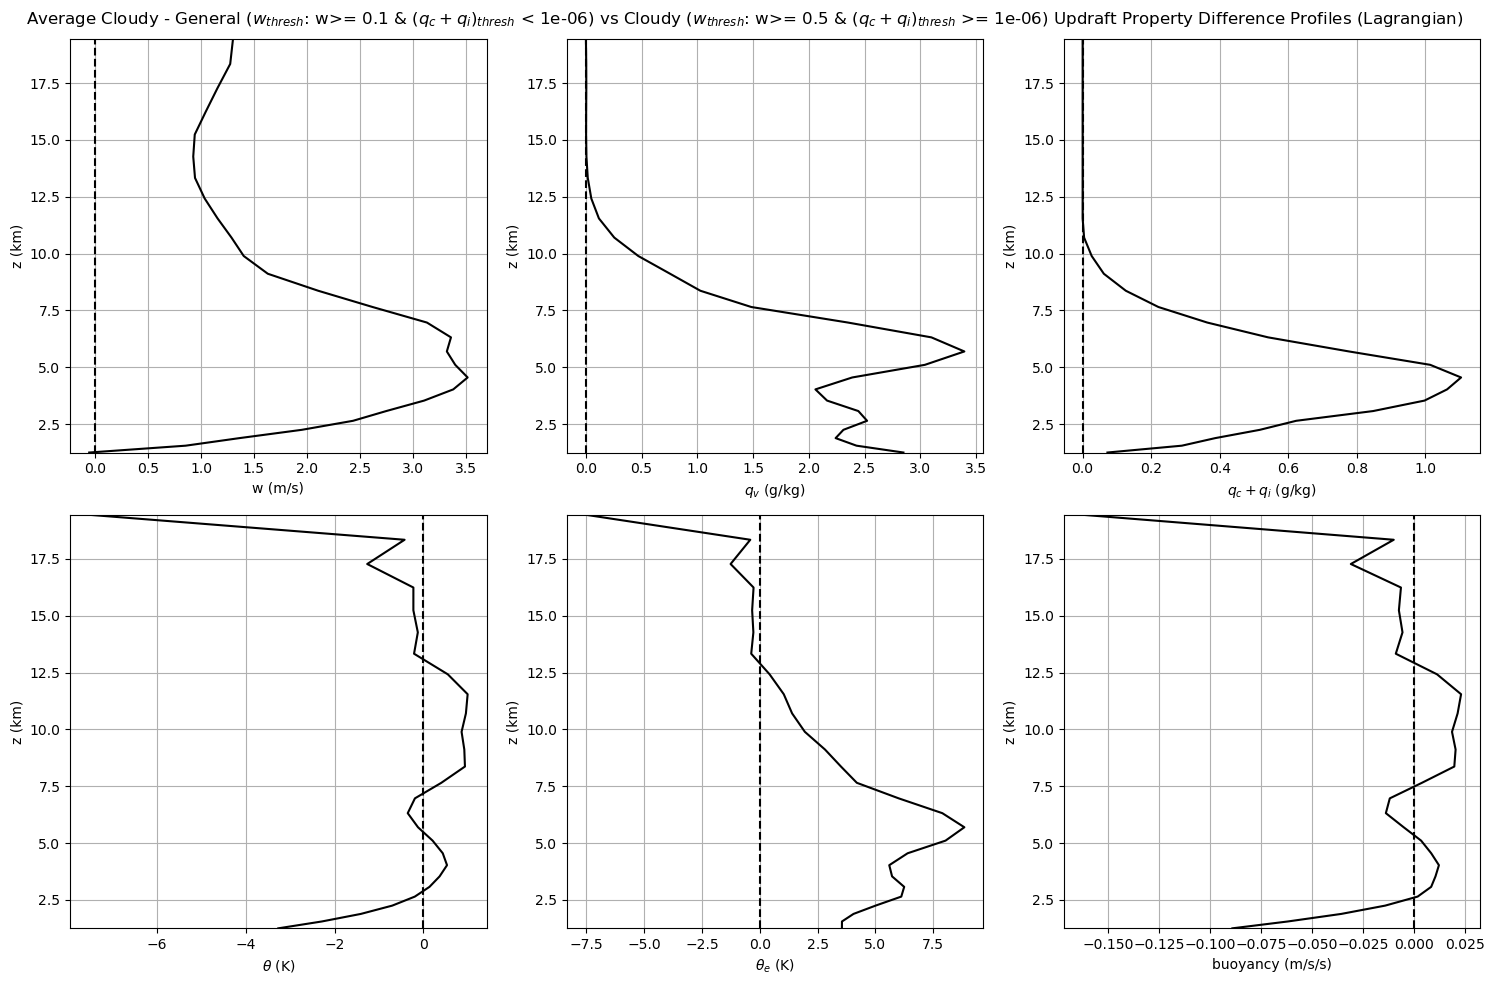

In [45]:
#Plotting Differences
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

res='1km'
def get_data(type):
    if res=='1km':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_{res}_{Np_str}.h5'
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_{res}_{Np_str}.h5'
    
    with h5py.File(input_file, 'r') as f:
        globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
        globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
        globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
        globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
        globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
        globals()[f'{type}_profile_th_e'] = np.array(f['profile_th_e'])
        globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])


    
def diff_plotting():
    #setting up figure
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f"Average Cloudy - General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Difference Profiles (Lagrangian)")
    ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

    #the plotting
    vars=['w','qv','qc','th','th_e','buoyancy']
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for xlabel,var in zip(xlabels,vars):
        
        if var=='w':axis=ax1
        if var=='qv':axis=ax2
        if var=='qc':axis=ax3
        if var=='th':axis=ax4
        if var=='th_e':axis=ax5
        if var=='buoyancy':axis=ax6

        #get profile
        types=['cloudy','general']
        get_data(types[0])
        out_var_one=globals()[f"{types[0]}_profile_{var}"]
        get_data(types[1])
        out_var_two=globals()[f"{types[1]}_profile_{var}"]

        #finding where cloudy updraft count goes below 10
        cutofflow=np.where(out_var_one[:,1]>10)[0][0]
        cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
  
        #averaging
        out_var_diff=average_difference(out_var_one,out_var_two)

        #(kg/kg) ==> (g/kg)
        if var=='qv' or var=='qc':
            out_var_diff[:,0]*=1000
            
        axis.plot(out_var_diff[:,0],out_var_diff[:,-1],color='k')
        axis.axvline(0,color='k',linestyle='dashed')
        # axis.set_ylim(bottom=0,top=20)
        axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
        #labeling
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.grid(True)
        # axis.legend(fontsize='small') #only adds legend at final variable

        # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
        
    plt.tight_layout()

# #MEAN CLOUD BASE
# for axis in axises:
#     axis.axhline(cloudbase,color='purple',linestyle='dashed')
    plt.savefig(dir+f'Project_Algorithms/plots/1km_lagrangian_updraft_profiles_diff_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) #save plot
diff_plotting() 